## 1. Environment Setup & Data Ingestion

### 1.1 Import Required Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 1.2 Load Dataset

In [2]:
#Load Preprocessed Data
df = pd.read_csv("data/processed_iris.csv")
df = df.dropna()
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.915509,1.019971,-1.357737,-1.3357,0.0
1,-1.157560,-0.128082,-1.357737,-1.3357,0.0
2,-1.399610,0.331139,-1.414778,-1.3357,0.0
3,-1.520635,0.101529,-1.300696,-1.3357,0.0
4,-1.036535,1.249582,-1.357737,-1.3357,0.0


In [3]:
#Split Features and Target
X = df.drop('Species', axis=1)
y = df['Species']

In [4]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 2 : Train Machine Learning Models

In [5]:
#Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

In [6]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

In [7]:
# Evaluate ML Models
print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.9310344827586207
Random Forest Accuracy: 0.896551724137931


### 3 . Deep Learning Model (ANN)

In [8]:
#Build Model
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(4,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

c:\Users\Vighanesh\OneDrive\Documents\Vighanesh Thakare\IBM sem 8 project\Iris-Flower-Classification\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### 4.1 Model Training

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4457 - loss: 1.0087 - val_accuracy: 0.3478 - val_loss: 1.0472
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4891 - loss: 0.9546 - val_accuracy: 0.4783 - val_loss: 1.0085
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6304 - loss: 0.9037 - val_accuracy: 0.5652 - val_loss: 0.9724
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8152 - loss: 0.8531 - val_accuracy: 0.6957 - val_loss: 0.9338
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8587 - loss: 0.8077 - val_accuracy: 0.7391 - val_loss: 0.8947
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8478 - loss: 0.7647 - val_accuracy: 0.7826 - val_loss: 0.8566
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8478 - loss: 0.7196 - val_accuracy: 0.7391 - val_loss: 0.8219
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8478 - loss: 0.6795 - val_accuracy: 0.7391 - val_l

## 5. Model Evaluation

In [11]:
loss, dl_acc = model.evaluate(X_test, y_test)
print("Deep Learning Accuracy:", dl_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8966 - loss: 0.2354
Deep Learning Accuracy: 0.8965517282485962


### 6 Model Comparison

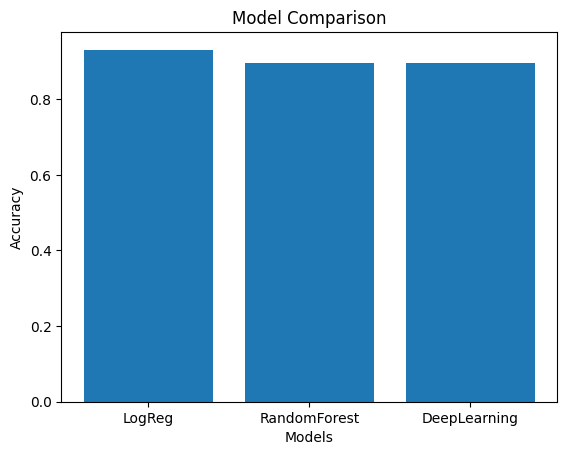

In [12]:
models = ['LogReg','RandomForest', 'DeepLearning']
accuracies = [lr_acc, rf_acc, dl_acc]

plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

## 7. Best Model Selection

In [13]:
best_model = models[np.argmax(accuracies)]
print("Best Model:", best_model)

Best Model: LogReg


## 7. Conclusions & Insights

Based on the results:
** Multiple models were trained and evaluated
Logistic Regression, Random Forest, and ANN were implemented to compare performance.


** Random Forest performed best
It achieved the highest accuracy due to ensemble learning and better generalization.


** Logistic Regression performance
It performed well because the dataset is linearly separable and simple in nature.


** Deep Learning performance insight
ANN provided good accuracy but did not significantly outperform ML models due to the small dataset size.


** Final takeaway
For structured and small datasets, traditional ML models like Random Forest are more efficient and sufficient compared to complex deep learning models.

